# WRDS Bank Regulatory Premium Summary

This notebook summarizes the WRDS Bank Regulatory Premium database tables.

## Tables Available

- **wrds_struct_rel_ultimate**: Ultimate parent structure relationships
- **wrds_call_research**: Call report research data (time series)
- **wrds_bank_crsp_link**: Bank to CRSP linkage table
- **idrssd_to_lei**: RSSD ID to LEI mapping
- **lei_main**: Legal Entity Identifier main table
- **lei_legalevents**: LEI legal events
- **lei_otherentnames**: LEI other entity names
- **lei_successorentity**: LEI successor entities

In [1]:
import sys
from pathlib import Path

sys.path.insert(1, "./src/")

import pandas as pd
import matplotlib.pyplot as plt
import chartbook

BASE_DIR = chartbook.env.get_project_root()
DATA_DIR = BASE_DIR / "_data"

## Table Sizes

In [2]:
tables = [
    "wrds_struct_rel_ultimate",
    "wrds_call_research",
    "wrds_bank_crsp_link",
    "idrssd_to_lei",
    "lei_main",
    "lei_legalevents",
    "lei_otherentnames",
    "lei_successorentity",
]

table_info = []
for table in tables:
    try:
        df = pd.read_parquet(DATA_DIR / f"{table}.parquet")
        table_info.append({
            "Table": table,
            "Rows": len(df),
            "Columns": len(df.columns)
        })
    except FileNotFoundError:
        table_info.append({
            "Table": table,
            "Rows": "Not found",
            "Columns": "N/A"
        })

info_df = pd.DataFrame(table_info)
print(info_df.to_string(index=False))

                   Table     Rows  Columns
wrds_struct_rel_ultimate 12621576       11
      wrds_call_research  2002806      372
     wrds_bank_crsp_link     1495        6
           idrssd_to_lei    36715        8
                lei_main 33620169        8
         lei_legalevents  1404312       12
       lei_otherentnames  1222254        7
     lei_successorentity    63369        7


## wrds_call_research - Time Series Data

In [3]:
call_research = pd.read_parquet(DATA_DIR / "wrds_call_research.parquet")
print(f"Shape: {call_research.shape}")
print(f"Date range: {call_research['date'].min()} to {call_research['date'].max()}")
print(f"Unique banks (rssd9001): {call_research['rssd9001'].nunique()}")

Shape: (2002806, 372)
Date range: 1976-03-31 00:00:00 to 2024-03-31 00:00:00
Unique banks (rssd9001): 24134


## Bank Coverage Over Time

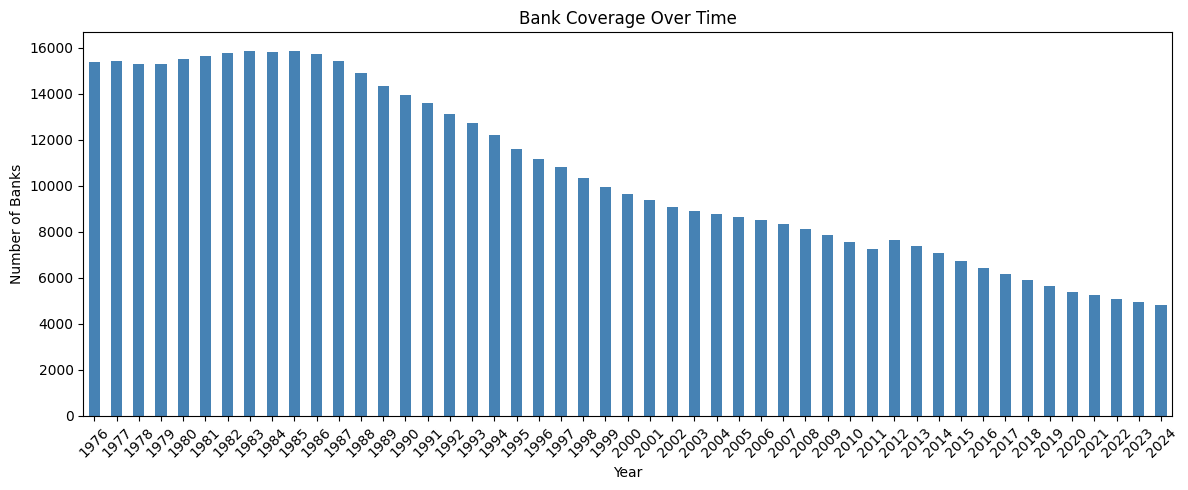

In [4]:
call_research["date"] = pd.to_datetime(call_research["date"])
call_research["year"] = call_research["date"].dt.year

banks_per_year = call_research.groupby("year")["rssd9001"].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
banks_per_year.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Banks")
ax.set_title("Bank Coverage Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## CRSP Linkage Statistics

In [5]:
crsp_link = pd.read_parquet(DATA_DIR / "wrds_bank_crsp_link.parquet")
print(f"Total linkages: {len(crsp_link)}")
print(f"Unique banks (rssd9001): {crsp_link['rssd9001'].nunique()}")
print(f"Unique CRSP permcos: {crsp_link['permco'].nunique()}")

Total linkages: 1495
Unique banks (rssd9001): 1492
Unique CRSP permcos: 1450


## LEI Coverage

In [6]:
idrssd_lei = pd.read_parquet(DATA_DIR / "idrssd_to_lei.parquet")
print(f"Total RSSD-LEI mappings: {len(idrssd_lei)}")
print(f"Unique RSSD IDs: {idrssd_lei['id_rssd'].nunique()}")

lei_main = pd.read_parquet(DATA_DIR / "lei_main.parquet")
print(f"\nLEI Main records: {len(lei_main)}")
print(f"Unique LEIs: {lei_main['lei'].nunique()}")

Total RSSD-LEI mappings: 36715
Unique RSSD IDs: 34914



LEI Main records: 33620169


Unique LEIs: 2809933


## FTSFR Dataset - Bank Total Assets

In [7]:
ftsfr_df = pd.read_parquet(DATA_DIR / "ftsfr_bank_total_assets.parquet")
print(f"Shape: {ftsfr_df.shape}")
print(f"Date range: {ftsfr_df['ds'].min()} to {ftsfr_df['ds'].max()}")
print(f"Unique banks: {ftsfr_df['unique_id'].nunique()}")

print("\nTotal Assets Summary (in thousands):")
print(ftsfr_df["y"].describe())


Shape: (1999371, 3)
Date range: 1976-03-31 00:00:00 to 2024-03-31 00:00:00
Unique banks: 24081

Total Assets Summary (in thousands):
count    1.999371e+06
mean     1.010370e+06
std      2.315980e+07
min      0.000000e+00
25%      2.467200e+04
50%      6.098900e+04
75%      1.720650e+05
max      3.503360e+09
Name: y, dtype: float64
